In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:
# ============================================================
# H1 & H2 Hypothesis Testing — Hindi Mental Lexicon Study
# Kaggle Single-Cell Version
# ============================================================
# SETUP: Add these datasets to your Kaggle notebook:
#   - final_vft_data.csv
#   - final_spam_cordinates.csv
#
# Internet must be ON (Settings → Internet → On)
# so that the model can be downloaded on first run.
# ============================================================

# ── 0. Install missing packages ──────────────────────────────
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip_install("sentence-transformers", "transformers", "torch")

# ── 1. Imports ───────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, wilcoxon
from scipy.spatial.distance import cdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize

# ── 2. File paths (Kaggle input directory) ───────────────────
import os

# Auto-detect input path — works whether files are in /kaggle/input/<dataset>/
# or uploaded directly to /kaggle/working/
def find_file(filename):
    for root, dirs, files in os.walk("/kaggle"):
        for f in files:
            if f == filename:
                return os.path.join(root, f)
    raise FileNotFoundError(f"{filename} not found under /kaggle. "
                            "Please add it as a dataset in the notebook.")

VFT_PATH  = find_file("final_vft_data.csv")
SPAM_PATH = find_file("final_spam_cordinates.csv")
print(f"VFT  path : {VFT_PATH}")
print(f"SpAM path : {SPAM_PATH}")

# ── 3. Config ────────────────────────────────────────────────
N_PERMUTATIONS = 5000
RNG_SEED       = 42

TRANSFORMER_MODELS = [
    "google/muril-base-cased",
    "ai4bharat/indic-bert",
    "sentence-transformers/LaBSE",
]
SBERT_FALLBACK = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

# ── 4. Load data ─────────────────────────────────────────────
print("\n" + "=" * 70)
print("LOADING DATA")
print("=" * 70)

vft  = pd.read_csv(VFT_PATH)
spam = pd.read_csv(SPAM_PATH)

vft["IRT"]        = vft["IRT"].astype(float)
vft["word_order"] = vft["word_order"].astype(int)

print(f"VFT  : {vft.shape[0]:>4d} rows | {vft.participant_id.nunique()} participants "
      f"| domains: {sorted(vft.domain.unique())}")
print(f"SpAM : {spam.shape[0]:>4d} rows | {spam.participant_id.nunique()} participants "
      f"| domains: {sorted(spam.domain.unique())}")

# ── 5. Embedding engine ──────────────────────────────────────
print("\nLoading embedding model …")

_embed_fn  = None
_model_tag = None

try:
    import torch
    from transformers import AutoTokenizer, AutoModel

    for model_name in TRANSFORMER_MODELS:
        try:
            print(f"  Trying {model_name} …")
            _tok = AutoTokenizer.from_pretrained(model_name)
            _mdl = AutoModel.from_pretrained(model_name)
            _mdl.eval()
            _dev = "cuda" if torch.cuda.is_available() else "cpu"
            _mdl.to(_dev)
            _model_tag = model_name
            print(f"  ✓  Loaded {model_name} on {_dev}")

            # def embed_words(word_list, batch_size=32):
            #     unique  = list(dict.fromkeys(word_list))
            #     idx_map = {w: i for i, w in enumerate(unique)}
            #     embs    = []
            #     for s in range(0, len(unique), batch_size):
            #         batch = unique[s:s + batch_size]
            #         enc   = _tok(batch, padding=True, truncation=True,
            #                      max_length=32, return_tensors="pt").to(_dev)
            #         with torch.no_grad():
            #             out = _mdl(**enc)
            #         mask = enc["attention_mask"].unsqueeze(-1).float()
            #         e    = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
            #         embs.append(e.cpu().numpy())
            #     u_embs = np.vstack(embs)
            #     return u_embs[[idx_map[w] for w in word_list]]

            def embed_words(word_list, batch_size=32):
                # Ensure all items are strings and remove duplicates/NaNs
                unique = [str(w) for w in dict.fromkeys(word_list) if pd.notna(w)]
                
                idx_map = {w: i for i, w in enumerate(unique)}
                embs = []
                for s in range(0, len(unique), batch_size):
                    batch = unique[s:s + batch_size]
                    # Tokenizer now strictly receives List[str]
                    enc = _tok(batch, padding=True, truncation=True,
                                 max_length=32, return_tensors="pt").to(_dev)
                    with torch.no_grad():
                        out = _mdl(**enc)
                    mask = enc["attention_mask"].unsqueeze(-1).float()
                    e = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
                    embs.append(e.cpu().numpy())
                
                if not embs:
                    return np.array([])
                    
                u_embs = np.vstack(embs)
                # Map back to the original word_list (handling potential missing NaNs)
                return u_embs[[idx_map[str(w)] for w in word_list if pd.notna(w)]]

            _embed_fn = embed_words
            break
        except Exception as exc:
            print(f"  ✗  {model_name} failed: {exc}")

except ImportError:
    print("  torch/transformers not available, trying sentence-transformers …")

if _embed_fn is None:
    try:
        from sentence_transformers import SentenceTransformer
        print(f"  Trying {SBERT_FALLBACK} …")
        _sbert     = SentenceTransformer(SBERT_FALLBACK)
        _model_tag = SBERT_FALLBACK

        # def embed_words(word_list, batch_size=64):
        #     unique  = list(dict.fromkeys(word_list))
        #     idx_map = {w: i for i, w in enumerate(unique)}
        #     u_embs  = _sbert.encode(unique, batch_size=batch_size,
        #                             show_progress_bar=False)
        #     return u_embs[[idx_map[w] for w in word_list]]

        def embed_words(word_list, batch_size=32):
                # Ensure all items are strings and remove duplicates/NaNs
                unique = [str(w) for w in dict.fromkeys(word_list) if pd.notna(w)]
                
                idx_map = {w: i for i, w in enumerate(unique)}
                embs = []
                for s in range(0, len(unique), batch_size):
                    batch = unique[s:s + batch_size]
                    # Tokenizer now strictly receives List[str]
                    enc = _tok(batch, padding=True, truncation=True,
                                 max_length=32, return_tensors="pt").to(_dev)
                    with torch.no_grad():
                        out = _mdl(**enc)
                    mask = enc["attention_mask"].unsqueeze(-1).float()
                    e = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
                    embs.append(e.cpu().numpy())
                
                if not embs:
                    return np.array([])
                    
                u_embs = np.vstack(embs)
                # Map back to the original word_list (handling potential missing NaNs)
                return u_embs[[idx_map[str(w)] for w in word_list if pd.notna(w)]]
        
        _embed_fn = embed_words
        print("  ✓  Loaded SentenceTransformer fallback")
    except Exception as exc:
        raise RuntimeError(
            f"All embedding models failed. Last error: {exc}\n"
            "Enable Internet in Kaggle Settings and re-run."
        )

print(f"\nEmbedding model in use: {_model_tag}\n")

# ── 6. Shared utilities ──────────────────────────────────────
def sqrt_k(n):
    return max(2, round(np.sqrt(n)))

def fisher_z(r):
    return np.arctanh(np.clip(r, -0.9999, 0.9999))

def label_transitions(session_df, cluster_col):
    df   = session_df.sort_values("word_order").copy()
    labs = df[cluster_col].values
    trans = [np.nan] + [
        "WC" if labs[i] == labs[i - 1] else "BC"
        for i in range(1, len(labs))
    ]
    df["transition"] = trans
    return df

def permutation_test_median_diff(wc_vals, bc_vals,
                                  n_perm=N_PERMUTATIONS, seed=RNG_SEED):
    rng      = np.random.default_rng(seed)
    combined = np.concatenate([wc_vals, bc_vals])
    n_wc     = len(wc_vals)
    observed = np.median(bc_vals) - np.median(wc_vals)
    count = sum(
        np.median(shuf[n_wc:]) - np.median(shuf[:n_wc]) >= observed
        for shuf in (rng.permutation(combined) for _ in range(n_perm))
    )
    return observed, (count + 1) / (n_perm + 1)

def permutation_test_spearman(x, y, n_perm=1000, seed=RNG_SEED):
    rng     = np.random.default_rng(seed)
    x, y    = np.asarray(x), np.asarray(y)
    obs_rho = spearmanr(x, y).statistic
    count   = sum(
        abs(spearmanr(x, rng.permutation(y)).statistic) >= abs(obs_rho)
        for _ in range(n_perm)
    )
    return obs_rho, (count + 1) / (n_perm + 1)

# ── 7. H1 — Option B: IndicBERT clusters ────────────────────
print("=" * 70)
print("H1 — OPTION B: IndicBERT Semantic Clusters → VFT IRT Transitions")
print("=" * 70)

print("Building domain-level cluster assignments …")
domain_emb_cache = {}

for domain in sorted(vft["domain"].unique()):
    sub   = vft[vft["domain"] == domain]
    words = sub["devnagri_word"].unique().tolist()
    k     = sqrt_k(len(words))
    print(f"  {domain:<14}: {len(words):>3d} unique words → k={k} clusters")
    embs   = embed_words(words)
    labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(normalize(embs))
    domain_emb_cache[domain] = dict(zip(words, labels.tolist()))

vft = vft.copy()
vft["cluster_indic"] = vft.apply(
    lambda r: domain_emb_cache[r["domain"]].get(r["devnagri_word"], -1), axis=1
)

labeled_b = pd.concat([
    label_transitions(grp, "cluster_indic")
    for _, grp in vft.groupby(["participant_id", "domain"])
], ignore_index=True)

trans_b  = labeled_b.dropna(subset=["transition"])
all_wc_b = trans_b[trans_b["transition"] == "WC"]["IRT"].values
all_bc_b = trans_b[trans_b["transition"] == "BC"]["IRT"].values

h1b_stats = []
for pid, grp in trans_b.groupby("participant_id"):
    wc = grp[grp["transition"] == "WC"]["IRT"].values
    bc = grp[grp["transition"] == "BC"]["IRT"].values
    if len(wc) >= 2 and len(bc) >= 2:
        h1b_stats.append(dict(participant_id=pid,
                               median_WC=np.median(wc), median_BC=np.median(bc),
                               n_WC=len(wc), n_BC=len(bc)))
h1b_df = pd.DataFrame(h1b_stats)

print(f"\n  Participants ≥2 WC & BC : {len(h1b_df)}")
print(f"  Median IRT WC : {np.median(all_wc_b):.1f} ms  |  BC : {np.median(all_bc_b):.1f} ms")
print(f"  Mean (BC−WC)  : {(h1b_df.median_BC - h1b_df.median_WC).mean():.1f} ms")

W_h1b, p_W_h1b = wilcoxon(h1b_df["median_BC"], h1b_df["median_WC"], alternative="greater")
print(f"\n  [H1-B Test 1] Wilcoxon: W={W_h1b:.3f}, p={p_W_h1b:.4f}  "
      f"{'*** SIGNIFICANT' if p_W_h1b < 0.05 else 'NOT SIGNIFICANT'}")

obs_h1b, p_perm_h1b = permutation_test_median_diff(all_wc_b, all_bc_b)
print(f"  [H1-B Test 2] Permutation: Δmedian={obs_h1b:.1f}ms, p={p_perm_h1b:.4f}  "
      f"{'*** SIGNIFICANT' if p_perm_h1b < 0.05 else 'NOT SIGNIFICANT'}")

# ── 8. H1 — Option C: SpAM clusters ─────────────────────────
print("\n" + "=" * 70)
print("H1 — OPTION C: SpAM-Geometric Clusters → VFT IRT Transitions")
print("=" * 70)

h1c_sessions    = []
agreement_flags = []

for (pid, dom), spam_grp in spam.groupby(["participant_id", "domain"]):
    if len(spam_grp) < 3:
        continue
    k      = sqrt_k(len(spam_grp))
    coords = spam_grp[["x_norm", "y_norm"]].values
    labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(coords)
    w2c    = dict(zip(spam_grp["devnagri_word"].values, labels.tolist()))

    sess = vft[(vft["participant_id"] == pid) & (vft["domain"] == dom)].copy()
    sess["cluster_spam"]  = sess["devnagri_word"].map(w2c)
    sess["cluster_indic"] = sess["devnagri_word"].map(domain_emb_cache[dom])

    sess_clean = sess.dropna(subset=["cluster_spam"])
    labeled    = label_transitions(sess_clean, "cluster_spam")
    labeled["participant_id"] = pid
    labeled["domain"]         = dom
    h1c_sessions.append(labeled)

    lt = labeled.dropna(subset=["transition"]).reset_index(drop=True)
    for i in range(len(lt)):
        row = lt.iloc[i]
        ci  = row["cluster_indic"]
        if i == 0 or pd.isna(ci):
            continue
        ci_prev = lt.iloc[i - 1]["cluster_indic"]
        if pd.isna(ci_prev):
            continue
        agreement_flags.append(row["transition"] == ("WC" if ci == ci_prev else "BC"))

vft_labeled_c = pd.concat(h1c_sessions, ignore_index=True)
trans_c  = vft_labeled_c.dropna(subset=["transition"])
all_wc_c = trans_c[trans_c["transition"] == "WC"]["IRT"].values
all_bc_c = trans_c[trans_c["transition"] == "BC"]["IRT"].values

h1c_stats = []
for pid, grp in trans_c.groupby("participant_id"):
    wc = grp[grp["transition"] == "WC"]["IRT"].values
    bc = grp[grp["transition"] == "BC"]["IRT"].values
    if len(wc) >= 2 and len(bc) >= 2:
        h1c_stats.append(dict(participant_id=pid,
                               median_WC=np.median(wc), median_BC=np.median(bc),
                               n_WC=len(wc), n_BC=len(bc)))
h1c_df = pd.DataFrame(h1c_stats)

print(f"  Participants ≥2 WC & BC : {len(h1c_df)}")
print(f"  Median IRT WC : {np.median(all_wc_c):.1f} ms  |  BC : {np.median(all_bc_c):.1f} ms")
print(f"  Mean (BC−WC)  : {(h1c_df.median_BC - h1c_df.median_WC).mean():.1f} ms")

W_h1c, p_W_h1c = wilcoxon(h1c_df["median_BC"], h1c_df["median_WC"], alternative="greater")
print(f"\n  [H1-C Test 1] Wilcoxon: W={W_h1c:.3f}, p={p_W_h1c:.4f}  "
      f"{'*** SIGNIFICANT' if p_W_h1c < 0.05 else 'NOT SIGNIFICANT'}")

obs_h1c, p_perm_h1c = permutation_test_median_diff(all_wc_c, all_bc_c)
print(f"  [H1-C Test 2] Permutation: Δmedian={obs_h1c:.1f}ms, p={p_perm_h1c:.4f}  "
      f"{'*** SIGNIFICANT' if p_perm_h1c < 0.05 else 'NOT SIGNIFICANT'}")

pct_agree = np.mean(agreement_flags) * 100
print(f"\n  SpAM ↔ IndicBERT WC/BC agreement : {pct_agree:.1f}%  (chance=50%)")









# ── 9. H2 — Option B: IndicBERT density × IRT ───────────────
h2b_records = []
for (pid, dom), grp in vft.groupby(["participant_id", "domain"]):
    grp = grp.sort_values("word_order").reset_index(drop=True)
    
    # CRITICAL FIX: Ensure we only use words that can be embedded
    # this aligns the length of irt_vals with the length of embs
    grp = grp.dropna(subset=["devnagri_word", "IRT"])
    words = grp["devnagri_word"].tolist()
    
    if len(words) < 4:
        continue
        
    embs = embed_words(words)
    
    # If embed_words filters internal duplicates, we must align grp to match
    # However, usually embed_words returns one emb per input word.
    # Let's ensure lengths match:
    if len(embs) != len(grp):
        # This fallback handles cases where embed_words might have dropped a row
        continue 

    cos_dist = cdist(normalize(embs), normalize(embs), metric="cosine")
    np.fill_diagonal(cos_dist, np.nan)
    mean_dist = np.nanmean(cos_dist, axis=1)
    irt_vals = grp["IRT"].values
    
    # Double check alignment before calling spearman
    if len(mean_dist) == len(irt_vals):
        if np.std(mean_dist) < 1e-9 or np.std(irt_vals) < 1e-9:
            continue
        rho, p_rho = spearmanr(mean_dist, irt_vals)
        _, p_perm = permutation_test_spearman(mean_dist, irt_vals, n_perm=1000)
        h2b_records.append(dict(participant_id=pid, domain=dom, n_words=len(words),
                                 rho=rho, fisher_z=fisher_z(rho),
                                 p_spearman=p_rho, p_perm=p_perm))
h2b_df = pd.DataFrame(h2b_records)
print(f"  Sessions analysed : {len(h2b_df)}")
print(f"  Mean Spearman ρ   : {h2b_df['rho'].mean():.3f}")

W_h2b, p_h2b = wilcoxon(h2b_df["fisher_z"], alternative="less")
print(f"\n  [H2-B] Wilcoxon (Fisher-z < 0): W={W_h2b:.3f}, p={p_h2b:.4f}  "
      f"{'*** SIGNIFICANT' if p_h2b < 0.05 else 'NOT SIGNIFICANT'}")

print(f"\n  {'Domain':<14} {'mean ρ':>7} {'n':>4}")
print("  " + "-" * 28)
for dom, sub in h2b_df.groupby("domain"):
    print(f"  {dom:<14} {sub['rho'].mean():>7.3f} {len(sub):>4}")

# ── 10. H2 — Option C: SpAM Euclidean density × IRT ─────────
print("\n" + "=" * 70)
print("H2 — OPTION C: SpAM Euclidean Density × IRT + IndicBERT cross-check")
print("=" * 70)

merged = vft.merge(
    spam[["participant_id", "domain", "devnagri_word", "x_norm", "y_norm"]],
    on=["participant_id", "domain", "devnagri_word"], how="inner"
)
print(f"  Words in both VFT & SpAM : {len(merged)}")

h2c_records = []
for (pid, dom), grp in merged.groupby(["participant_id", "domain"]):
    if len(grp) < 4:
        continue
    coords   = grp[["x_norm", "y_norm"]].values
    euc_dist = cdist(coords, coords, metric="euclidean")
    np.fill_diagonal(euc_dist, np.nan)
    mean_euc = np.nanmean(euc_dist, axis=1)
    irt_vals = grp["IRT"].values
    if np.std(mean_euc) < 1e-9 or np.std(irt_vals) < 1e-9:
        continue
    rho_spam, p_spam = spearmanr(mean_euc, irt_vals)
    _, p_perm_spam   = permutation_test_spearman(mean_euc, irt_vals, n_perm=1000)

    words    = grp["devnagri_word"].tolist()
    embs     = embed_words(words)
    cos_dist = cdist(normalize(embs), normalize(embs), metric="cosine")
    np.fill_diagonal(cos_dist, np.nan)
    mean_cos = np.nanmean(cos_dist, axis=1)
    rho_ind, p_ind = spearmanr(mean_cos, irt_vals)

    h2c_records.append(dict(participant_id=pid, domain=dom, n_words=len(grp),
                             rho_spam=rho_spam, fz_spam=fisher_z(rho_spam),
                             p_spam=p_spam, p_perm_spam=p_perm_spam,
                             rho_indic=rho_ind, fz_indic=fisher_z(rho_ind), p_indic=p_ind))

h2c_df = pd.DataFrame(h2c_records)
print(f"  Sessions analysed : {len(h2c_df)}")

W_spam, p_spam_w = wilcoxon(h2c_df["fz_spam"], alternative="less")
print(f"\n  [H2-C SpAM]     Wilcoxon: W={W_spam:.3f}, p={p_spam_w:.4f}  "
      f"{'*** SIGNIFICANT' if p_spam_w < 0.05 else 'NOT SIGNIFICANT'}  "
      f"(mean ρ={h2c_df['rho_spam'].mean():.3f})")

W_ind, p_ind_w = wilcoxon(h2c_df["fz_indic"], alternative="less")
print(f"  [H2-C IndicBERT] Wilcoxon: W={W_ind:.3f}, p={p_ind_w:.4f}  "
      f"{'*** SIGNIFICANT' if p_ind_w < 0.05 else 'NOT SIGNIFICANT'}  "
      f"(mean ρ={h2c_df['rho_indic'].mean():.3f})")

rho_cross, p_cross = spearmanr(h2c_df["rho_spam"], h2c_df["rho_indic"])
print(f"\n  Cross-method ρ = {rho_cross:.3f}, p = {p_cross:.4f}  "
      f"→ {'Methods agree' if rho_cross > 0 else 'Methods diverge'}")

print(f"\n  {'Domain':<14} {'ρ_SpAM':>8} {'ρ_IndicBERT':>12} {'n':>4}")
print("  " + "-" * 44)
for dom, sub in h2c_df.groupby("domain"):
    print(f"  {dom:<14} {sub['rho_spam'].mean():>8.3f} "
          f"{sub['rho_indic'].mean():>12.3f} {len(sub):>4}")

# ── 11. Final summary ─────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)

rows = [
    ("H1-B", "IndicBERT clusters → IRT",      "Wilcoxon (BC>WC)",          f"W={W_h1b:.1f}, p={p_W_h1b:.4f}",    p_W_h1b),
    ("H1-B", "IndicBERT clusters → IRT",      f"Permutation ({N_PERMUTATIONS})",  f"Δ={obs_h1b:.0f}ms, p={p_perm_h1b:.4f}", p_perm_h1b),
    ("H1-C", "SpAM clusters → IRT",           "Wilcoxon (BC>WC)",          f"W={W_h1c:.1f}, p={p_W_h1c:.4f}",    p_W_h1c),
    ("H1-C", "SpAM clusters → IRT",           f"Permutation ({N_PERMUTATIONS})",  f"Δ={obs_h1c:.0f}ms, p={p_perm_h1c:.4f}", p_perm_h1c),
    ("H2-B", "IndicBERT density × IRT",       "Wilcoxon Fisher-z < 0",     f"W={W_h2b:.1f}, p={p_h2b:.4f}",      p_h2b),
    ("H2-C", "SpAM density × IRT",            "Wilcoxon Fisher-z < 0",     f"W={W_spam:.1f}, p={p_spam_w:.4f}",   p_spam_w),
    ("H2-C", "IndicBERT density × IRT (matched)", "Wilcoxon Fisher-z < 0", f"W={W_ind:.1f}, p={p_ind_w:.4f}",    p_ind_w),
]

print(f"\n  {'Hyp':<6} {'Description':<30} {'Test':<28} {'Result':<28} Sig?")
print("  " + "-" * 100)
for hyp, desc, test, result, p in rows:
    print(f"  {hyp:<6} {desc:<30} {test:<28} {result:<28} {'✓ *' if p < 0.05 else '✗'}")

print(f"\n  SpAM ↔ IndicBERT agreement (H1) : {pct_agree:.1f}%")
print(f"  Cross-method ρ (H2 per session) : {rho_cross:.3f} (p={p_cross:.4f})")
print(f"  Model used : {_model_tag}")
print("\nDone ✓")

VFT  path : /kaggle/input/datasets/suyashnpande/final-brsm-dataset/final_vft_data.csv
SpAM path : /kaggle/input/datasets/suyashnpande/final-brsm-dataset/final_spam_cordinates.csv

LOADING DATA
VFT  :  691 rows | 27 participants | domains: ['animals', 'body-parts', 'colours', 'foods']
SpAM :  682 rows | 27 participants | domains: ['animals', 'body-parts', 'colours', 'foods']

Loading embedding model …
  Trying google/muril-base-cased …


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓  Loaded google/muril-base-cased on cuda

Embedding model in use: google/muril-base-cased

H1 — OPTION B: IndicBERT Semantic Clusters → VFT IRT Transitions
Building domain-level cluster assignments …
  animals       :  55 unique words → k=7 clusters
  body-parts    :  51 unique words → k=7 clusters
  colours       :  17 unique words → k=4 clusters
  foods         :  99 unique words → k=10 clusters

  Participants ≥2 WC & BC : 26
  Median IRT WC : 4914.9 ms  |  BC : 5158.6 ms
  Mean (BC−WC)  : 1180.8 ms

  [H1-B Test 1] Wilcoxon: W=291.000, p=0.0012  *** SIGNIFICANT
  [H1-B Test 2] Permutation: Δmedian=243.7ms, p=0.2352  NOT SIGNIFICANT

H1 — OPTION C: SpAM-Geometric Clusters → VFT IRT Transitions
  Participants ≥2 WC & BC : 25
  Median IRT WC : 4806.0 ms  |  BC : 5766.8 ms
  Mean (BC−WC)  : 846.4 ms

  [H1-C Test 1] Wilcoxon: W=246.000, p=0.0118  *** SIGNIFICANT
  [H1-C Test 2] Permutation: Δmedian=960.8ms, p=0.0068  *** SIGNIFICANT

  SpAM ↔ IndicBERT WC/BC agreement : 50.9%  (chan

In [7]:
# ============================================================
# H1 & H2 Hypothesis Testing — Hindi Mental Lexicon Study
# Kaggle Single-Cell Version
# ============================================================
# SETUP: Add these datasets to your Kaggle notebook:
#   - final_vft_data.csv
#   - final_spam_cordinates.csv
#
# Internet must be ON (Settings → Internet → On)
# so that the model can be downloaded on first run.
# ============================================================

# ── 0. Install missing packages ──────────────────────────────
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip_install("sentence-transformers", "transformers", "torch")

# ── 1. Imports ───────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, wilcoxon
from scipy.spatial.distance import cdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize

# ── 2. File paths (Kaggle input directory) ───────────────────
import os

# Auto-detect input path — works whether files are in /kaggle/input/<dataset>/
# or uploaded directly to /kaggle/working/
def find_file(filename):
    for root, dirs, files in os.walk("/kaggle"):
        for f in files:
            if f == filename:
                return os.path.join(root, f)
    raise FileNotFoundError(f"{filename} not found under /kaggle. "
                            "Please add it as a dataset in the notebook.")

VFT_PATH  = find_file("final_vft_data.csv")
SPAM_PATH = find_file("final_spam_cordinates.csv")
print(f"VFT  path : {VFT_PATH}")
print(f"SpAM path : {SPAM_PATH}")

# ── 3. Config ────────────────────────────────────────────────
N_PERMUTATIONS = 5000
RNG_SEED       = 42

TRANSFORMER_MODELS = [
    "ai4bharat/indic-bert",
    "sentence-transformers/LaBSE",
]
SBERT_FALLBACK = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

# ── 4. Load data ─────────────────────────────────────────────
print("\n" + "=" * 70)
print("LOADING DATA")
print("=" * 70)

vft  = pd.read_csv(VFT_PATH)
spam = pd.read_csv(SPAM_PATH)

vft["IRT"]        = vft["IRT"].astype(float)
vft["word_order"] = vft["word_order"].astype(int)

print(f"VFT  : {vft.shape[0]:>4d} rows | {vft.participant_id.nunique()} participants "
      f"| domains: {sorted(vft.domain.unique())}")
print(f"SpAM : {spam.shape[0]:>4d} rows | {spam.participant_id.nunique()} participants "
      f"| domains: {sorted(spam.domain.unique())}")

# ── 5. Embedding engine ──────────────────────────────────────
print("\nLoading embedding model …")

_embed_fn  = None
_model_tag = None

try:
    import torch
    from transformers import AutoTokenizer, AutoModel

    for model_name in TRANSFORMER_MODELS:
        try:
            print(f"  Trying {model_name} …")
            _tok = AutoTokenizer.from_pretrained(model_name)
            _mdl = AutoModel.from_pretrained(model_name)
            _mdl.eval()
            _dev = "cuda" if torch.cuda.is_available() else "cpu"
            _mdl.to(_dev)
            _model_tag = model_name
            print(f"  ✓  Loaded {model_name} on {_dev}")

            # def embed_words(word_list, batch_size=32):
            #     unique  = list(dict.fromkeys(word_list))
            #     idx_map = {w: i for i, w in enumerate(unique)}
            #     embs    = []
            #     for s in range(0, len(unique), batch_size):
            #         batch = unique[s:s + batch_size]
            #         enc   = _tok(batch, padding=True, truncation=True,
            #                      max_length=32, return_tensors="pt").to(_dev)
            #         with torch.no_grad():
            #             out = _mdl(**enc)
            #         mask = enc["attention_mask"].unsqueeze(-1).float()
            #         e    = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
            #         embs.append(e.cpu().numpy())
            #     u_embs = np.vstack(embs)
            #     return u_embs[[idx_map[w] for w in word_list]]

            def embed_words(word_list, batch_size=32):
                # Ensure all items are strings and remove duplicates/NaNs
                unique = [str(w) for w in dict.fromkeys(word_list) if pd.notna(w)]
                
                idx_map = {w: i for i, w in enumerate(unique)}
                embs = []
                for s in range(0, len(unique), batch_size):
                    batch = unique[s:s + batch_size]
                    # Tokenizer now strictly receives List[str]
                    enc = _tok(batch, padding=True, truncation=True,
                                 max_length=32, return_tensors="pt").to(_dev)
                    with torch.no_grad():
                        out = _mdl(**enc)
                    mask = enc["attention_mask"].unsqueeze(-1).float()
                    e = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
                    embs.append(e.cpu().numpy())
                
                if not embs:
                    return np.array([])
                    
                u_embs = np.vstack(embs)
                # Map back to the original word_list (handling potential missing NaNs)
                return u_embs[[idx_map[str(w)] for w in word_list if pd.notna(w)]]

            _embed_fn = embed_words
            break
        except Exception as exc:
            print(f"  ✗  {model_name} failed: {exc}")

except ImportError:
    print("  torch/transformers not available, trying sentence-transformers …")

if _embed_fn is None:
    try:
        from sentence_transformers import SentenceTransformer
        print(f"  Trying {SBERT_FALLBACK} …")
        _sbert     = SentenceTransformer(SBERT_FALLBACK)
        _model_tag = SBERT_FALLBACK

        # def embed_words(word_list, batch_size=64):
        #     unique  = list(dict.fromkeys(word_list))
        #     idx_map = {w: i for i, w in enumerate(unique)}
        #     u_embs  = _sbert.encode(unique, batch_size=batch_size,
        #                             show_progress_bar=False)
        #     return u_embs[[idx_map[w] for w in word_list]]

        def embed_words(word_list, batch_size=32):
                # Ensure all items are strings and remove duplicates/NaNs
                unique = [str(w) for w in dict.fromkeys(word_list) if pd.notna(w)]
                
                idx_map = {w: i for i, w in enumerate(unique)}
                embs = []
                for s in range(0, len(unique), batch_size):
                    batch = unique[s:s + batch_size]
                    # Tokenizer now strictly receives List[str]
                    enc = _tok(batch, padding=True, truncation=True,
                                 max_length=32, return_tensors="pt").to(_dev)
                    with torch.no_grad():
                        out = _mdl(**enc)
                    mask = enc["attention_mask"].unsqueeze(-1).float()
                    e = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
                    embs.append(e.cpu().numpy())
                
                if not embs:
                    return np.array([])
                    
                u_embs = np.vstack(embs)
                # Map back to the original word_list (handling potential missing NaNs)
                return u_embs[[idx_map[str(w)] for w in word_list if pd.notna(w)]]
        
        _embed_fn = embed_words
        print("  ✓  Loaded SentenceTransformer fallback")
    except Exception as exc:
        raise RuntimeError(
            f"All embedding models failed. Last error: {exc}\n"
            "Enable Internet in Kaggle Settings and re-run."
        )

print(f"\nEmbedding model in use: {_model_tag}\n")

# ── 6. Shared utilities ──────────────────────────────────────
def sqrt_k(n):
    return max(2, round(np.sqrt(n)))

def fisher_z(r):
    return np.arctanh(np.clip(r, -0.9999, 0.9999))

def label_transitions(session_df, cluster_col):
    df   = session_df.sort_values("word_order").copy()
    labs = df[cluster_col].values
    trans = [np.nan] + [
        "WC" if labs[i] == labs[i - 1] else "BC"
        for i in range(1, len(labs))
    ]
    df["transition"] = trans
    return df

def permutation_test_median_diff(wc_vals, bc_vals,
                                  n_perm=N_PERMUTATIONS, seed=RNG_SEED):
    rng      = np.random.default_rng(seed)
    combined = np.concatenate([wc_vals, bc_vals])
    n_wc     = len(wc_vals)
    observed = np.median(bc_vals) - np.median(wc_vals)
    count = sum(
        np.median(shuf[n_wc:]) - np.median(shuf[:n_wc]) >= observed
        for shuf in (rng.permutation(combined) for _ in range(n_perm))
    )
    return observed, (count + 1) / (n_perm + 1)

def permutation_test_spearman(x, y, n_perm=1000, seed=RNG_SEED):
    rng     = np.random.default_rng(seed)
    x, y    = np.asarray(x), np.asarray(y)
    obs_rho = spearmanr(x, y).statistic
    count   = sum(
        abs(spearmanr(x, rng.permutation(y)).statistic) >= abs(obs_rho)
        for _ in range(n_perm)
    )
    return obs_rho, (count + 1) / (n_perm + 1)

# ── 7. H1 — Option B: IndicBERT clusters ────────────────────
print("=" * 70)
print("H1 — OPTION B: IndicBERT Semantic Clusters → VFT IRT Transitions")
print("=" * 70)

print("Building domain-level cluster assignments …")
domain_emb_cache = {}

for domain in sorted(vft["domain"].unique()):
    sub   = vft[vft["domain"] == domain]
    words = sub["devnagri_word"].unique().tolist()
    k     = sqrt_k(len(words))
    print(f"  {domain:<14}: {len(words):>3d} unique words → k={k} clusters")
    embs   = embed_words(words)
    labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(normalize(embs))
    domain_emb_cache[domain] = dict(zip(words, labels.tolist()))

vft = vft.copy()
vft["cluster_indic"] = vft.apply(
    lambda r: domain_emb_cache[r["domain"]].get(r["devnagri_word"], -1), axis=1
)

labeled_b = pd.concat([
    label_transitions(grp, "cluster_indic")
    for _, grp in vft.groupby(["participant_id", "domain"])
], ignore_index=True)

trans_b  = labeled_b.dropna(subset=["transition"])
all_wc_b = trans_b[trans_b["transition"] == "WC"]["IRT"].values
all_bc_b = trans_b[trans_b["transition"] == "BC"]["IRT"].values

h1b_stats = []
for pid, grp in trans_b.groupby("participant_id"):
    wc = grp[grp["transition"] == "WC"]["IRT"].values
    bc = grp[grp["transition"] == "BC"]["IRT"].values
    if len(wc) >= 2 and len(bc) >= 2:
        h1b_stats.append(dict(participant_id=pid,
                               median_WC=np.median(wc), median_BC=np.median(bc),
                               n_WC=len(wc), n_BC=len(bc)))
h1b_df = pd.DataFrame(h1b_stats)

print(f"\n  Participants ≥2 WC & BC : {len(h1b_df)}")
print(f"  Median IRT WC : {np.median(all_wc_b):.1f} ms  |  BC : {np.median(all_bc_b):.1f} ms")
print(f"  Mean (BC−WC)  : {(h1b_df.median_BC - h1b_df.median_WC).mean():.1f} ms")

W_h1b, p_W_h1b = wilcoxon(h1b_df["median_BC"], h1b_df["median_WC"], alternative="greater")
print(f"\n  [H1-B Test 1] Wilcoxon: W={W_h1b:.3f}, p={p_W_h1b:.4f}  "
      f"{'*** SIGNIFICANT' if p_W_h1b < 0.05 else 'NOT SIGNIFICANT'}")

obs_h1b, p_perm_h1b = permutation_test_median_diff(all_wc_b, all_bc_b)
print(f"  [H1-B Test 2] Permutation: Δmedian={obs_h1b:.1f}ms, p={p_perm_h1b:.4f}  "
      f"{'*** SIGNIFICANT' if p_perm_h1b < 0.05 else 'NOT SIGNIFICANT'}")

# ── 8. H1 — Option C: SpAM clusters ─────────────────────────
print("\n" + "=" * 70)
print("H1 — OPTION C: SpAM-Geometric Clusters → VFT IRT Transitions")
print("=" * 70)

h1c_sessions    = []
agreement_flags = []

for (pid, dom), spam_grp in spam.groupby(["participant_id", "domain"]):
    if len(spam_grp) < 3:
        continue
    k      = sqrt_k(len(spam_grp))
    coords = spam_grp[["x_norm", "y_norm"]].values
    labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(coords)
    w2c    = dict(zip(spam_grp["devnagri_word"].values, labels.tolist()))

    sess = vft[(vft["participant_id"] == pid) & (vft["domain"] == dom)].copy()
    sess["cluster_spam"]  = sess["devnagri_word"].map(w2c)
    sess["cluster_indic"] = sess["devnagri_word"].map(domain_emb_cache[dom])

    sess_clean = sess.dropna(subset=["cluster_spam"])
    labeled    = label_transitions(sess_clean, "cluster_spam")
    labeled["participant_id"] = pid
    labeled["domain"]         = dom
    h1c_sessions.append(labeled)

    lt = labeled.dropna(subset=["transition"]).reset_index(drop=True)
    for i in range(len(lt)):
        row = lt.iloc[i]
        ci  = row["cluster_indic"]
        if i == 0 or pd.isna(ci):
            continue
        ci_prev = lt.iloc[i - 1]["cluster_indic"]
        if pd.isna(ci_prev):
            continue
        agreement_flags.append(row["transition"] == ("WC" if ci == ci_prev else "BC"))

vft_labeled_c = pd.concat(h1c_sessions, ignore_index=True)
trans_c  = vft_labeled_c.dropna(subset=["transition"])
all_wc_c = trans_c[trans_c["transition"] == "WC"]["IRT"].values
all_bc_c = trans_c[trans_c["transition"] == "BC"]["IRT"].values

h1c_stats = []
for pid, grp in trans_c.groupby("participant_id"):
    wc = grp[grp["transition"] == "WC"]["IRT"].values
    bc = grp[grp["transition"] == "BC"]["IRT"].values
    if len(wc) >= 2 and len(bc) >= 2:
        h1c_stats.append(dict(participant_id=pid,
                               median_WC=np.median(wc), median_BC=np.median(bc),
                               n_WC=len(wc), n_BC=len(bc)))
h1c_df = pd.DataFrame(h1c_stats)

print(f"  Participants ≥2 WC & BC : {len(h1c_df)}")
print(f"  Median IRT WC : {np.median(all_wc_c):.1f} ms  |  BC : {np.median(all_bc_c):.1f} ms")
print(f"  Mean (BC−WC)  : {(h1c_df.median_BC - h1c_df.median_WC).mean():.1f} ms")

W_h1c, p_W_h1c = wilcoxon(h1c_df["median_BC"], h1c_df["median_WC"], alternative="greater")
print(f"\n  [H1-C Test 1] Wilcoxon: W={W_h1c:.3f}, p={p_W_h1c:.4f}  "
      f"{'*** SIGNIFICANT' if p_W_h1c < 0.05 else 'NOT SIGNIFICANT'}")

obs_h1c, p_perm_h1c = permutation_test_median_diff(all_wc_c, all_bc_c)
print(f"  [H1-C Test 2] Permutation: Δmedian={obs_h1c:.1f}ms, p={p_perm_h1c:.4f}  "
      f"{'*** SIGNIFICANT' if p_perm_h1c < 0.05 else 'NOT SIGNIFICANT'}")

pct_agree = np.mean(agreement_flags) * 100
print(f"\n  SpAM ↔ IndicBERT WC/BC agreement : {pct_agree:.1f}%  (chance=50%)")









# ── 9. H2 — Option B: IndicBERT density × IRT ───────────────
h2b_records = []
for (pid, dom), grp in vft.groupby(["participant_id", "domain"]):
    grp = grp.sort_values("word_order").reset_index(drop=True)
    
    # CRITICAL FIX: Ensure we only use words that can be embedded
    # this aligns the length of irt_vals with the length of embs
    grp = grp.dropna(subset=["devnagri_word", "IRT"])
    words = grp["devnagri_word"].tolist()
    
    if len(words) < 4:
        continue
        
    embs = embed_words(words)
    
    # If embed_words filters internal duplicates, we must align grp to match
    # However, usually embed_words returns one emb per input word.
    # Let's ensure lengths match:
    if len(embs) != len(grp):
        # This fallback handles cases where embed_words might have dropped a row
        continue 

    cos_dist = cdist(normalize(embs), normalize(embs), metric="cosine")
    np.fill_diagonal(cos_dist, np.nan)
    mean_dist = np.nanmean(cos_dist, axis=1)
    irt_vals = grp["IRT"].values
    
    # Double check alignment before calling spearman
    if len(mean_dist) == len(irt_vals):
        if np.std(mean_dist) < 1e-9 or np.std(irt_vals) < 1e-9:
            continue
        rho, p_rho = spearmanr(mean_dist, irt_vals)
        _, p_perm = permutation_test_spearman(mean_dist, irt_vals, n_perm=1000)
        h2b_records.append(dict(participant_id=pid, domain=dom, n_words=len(words),
                                 rho=rho, fisher_z=fisher_z(rho),
                                 p_spearman=p_rho, p_perm=p_perm))
h2b_df = pd.DataFrame(h2b_records)
print(f"  Sessions analysed : {len(h2b_df)}")
print(f"  Mean Spearman ρ   : {h2b_df['rho'].mean():.3f}")

W_h2b, p_h2b = wilcoxon(h2b_df["fisher_z"], alternative="less")
print(f"\n  [H2-B] Wilcoxon (Fisher-z < 0): W={W_h2b:.3f}, p={p_h2b:.4f}  "
      f"{'*** SIGNIFICANT' if p_h2b < 0.05 else 'NOT SIGNIFICANT'}")

print(f"\n  {'Domain':<14} {'mean ρ':>7} {'n':>4}")
print("  " + "-" * 28)
for dom, sub in h2b_df.groupby("domain"):
    print(f"  {dom:<14} {sub['rho'].mean():>7.3f} {len(sub):>4}")

# ── 10. H2 — Option C: SpAM Euclidean density × IRT ─────────
print("\n" + "=" * 70)
print("H2 — OPTION C: SpAM Euclidean Density × IRT + IndicBERT cross-check")
print("=" * 70)

merged = vft.merge(
    spam[["participant_id", "domain", "devnagri_word", "x_norm", "y_norm"]],
    on=["participant_id", "domain", "devnagri_word"], how="inner"
)
print(f"  Words in both VFT & SpAM : {len(merged)}")

h2c_records = []
for (pid, dom), grp in merged.groupby(["participant_id", "domain"]):
    if len(grp) < 4:
        continue
    coords   = grp[["x_norm", "y_norm"]].values
    euc_dist = cdist(coords, coords, metric="euclidean")
    np.fill_diagonal(euc_dist, np.nan)
    mean_euc = np.nanmean(euc_dist, axis=1)
    irt_vals = grp["IRT"].values
    if np.std(mean_euc) < 1e-9 or np.std(irt_vals) < 1e-9:
        continue
    rho_spam, p_spam = spearmanr(mean_euc, irt_vals)
    _, p_perm_spam   = permutation_test_spearman(mean_euc, irt_vals, n_perm=1000)

    words    = grp["devnagri_word"].tolist()
    embs     = embed_words(words)
    cos_dist = cdist(normalize(embs), normalize(embs), metric="cosine")
    np.fill_diagonal(cos_dist, np.nan)
    mean_cos = np.nanmean(cos_dist, axis=1)
    rho_ind, p_ind = spearmanr(mean_cos, irt_vals)

    h2c_records.append(dict(participant_id=pid, domain=dom, n_words=len(grp),
                             rho_spam=rho_spam, fz_spam=fisher_z(rho_spam),
                             p_spam=p_spam, p_perm_spam=p_perm_spam,
                             rho_indic=rho_ind, fz_indic=fisher_z(rho_ind), p_indic=p_ind))

h2c_df = pd.DataFrame(h2c_records)
print(f"  Sessions analysed : {len(h2c_df)}")

W_spam, p_spam_w = wilcoxon(h2c_df["fz_spam"], alternative="less")
print(f"\n  [H2-C SpAM]     Wilcoxon: W={W_spam:.3f}, p={p_spam_w:.4f}  "
      f"{'*** SIGNIFICANT' if p_spam_w < 0.05 else 'NOT SIGNIFICANT'}  "
      f"(mean ρ={h2c_df['rho_spam'].mean():.3f})")

W_ind, p_ind_w = wilcoxon(h2c_df["fz_indic"], alternative="less")
print(f"  [H2-C IndicBERT] Wilcoxon: W={W_ind:.3f}, p={p_ind_w:.4f}  "
      f"{'*** SIGNIFICANT' if p_ind_w < 0.05 else 'NOT SIGNIFICANT'}  "
      f"(mean ρ={h2c_df['rho_indic'].mean():.3f})")

rho_cross, p_cross = spearmanr(h2c_df["rho_spam"], h2c_df["rho_indic"])
print(f"\n  Cross-method ρ = {rho_cross:.3f}, p = {p_cross:.4f}  "
      f"→ {'Methods agree' if rho_cross > 0 else 'Methods diverge'}")

print(f"\n  {'Domain':<14} {'ρ_SpAM':>8} {'ρ_IndicBERT':>12} {'n':>4}")
print("  " + "-" * 44)
for dom, sub in h2c_df.groupby("domain"):
    print(f"  {dom:<14} {sub['rho_spam'].mean():>8.3f} "
          f"{sub['rho_indic'].mean():>12.3f} {len(sub):>4}")

# ── 11. Final summary ─────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)

rows = [
    ("H1-B", "IndicBERT clusters → IRT",      "Wilcoxon (BC>WC)",          f"W={W_h1b:.1f}, p={p_W_h1b:.4f}",    p_W_h1b),
    ("H1-B", "IndicBERT clusters → IRT",      f"Permutation ({N_PERMUTATIONS})",  f"Δ={obs_h1b:.0f}ms, p={p_perm_h1b:.4f}", p_perm_h1b),
    ("H1-C", "SpAM clusters → IRT",           "Wilcoxon (BC>WC)",          f"W={W_h1c:.1f}, p={p_W_h1c:.4f}",    p_W_h1c),
    ("H1-C", "SpAM clusters → IRT",           f"Permutation ({N_PERMUTATIONS})",  f"Δ={obs_h1c:.0f}ms, p={p_perm_h1c:.4f}", p_perm_h1c),
    ("H2-B", "IndicBERT density × IRT",       "Wilcoxon Fisher-z < 0",     f"W={W_h2b:.1f}, p={p_h2b:.4f}",      p_h2b),
    ("H2-C", "SpAM density × IRT",            "Wilcoxon Fisher-z < 0",     f"W={W_spam:.1f}, p={p_spam_w:.4f}",   p_spam_w),
    ("H2-C", "IndicBERT density × IRT (matched)", "Wilcoxon Fisher-z < 0", f"W={W_ind:.1f}, p={p_ind_w:.4f}",    p_ind_w),
]

print(f"\n  {'Hyp':<6} {'Description':<30} {'Test':<28} {'Result':<28} Sig?")
print("  " + "-" * 100)
for hyp, desc, test, result, p in rows:
    print(f"  {hyp:<6} {desc:<30} {test:<28} {result:<28} {'✓ *' if p < 0.05 else '✗'}")

print(f"\n  SpAM ↔ IndicBERT agreement (H1) : {pct_agree:.1f}%")
print(f"  Cross-method ρ (H2 per session) : {rho_cross:.3f} (p={p_cross:.4f})")
print(f"  Model used : {_model_tag}")
print("\nDone ✓")

VFT  path : /kaggle/input/datasets/suyashnpande/final-brsm-dataset/final_vft_data.csv
SpAM path : /kaggle/input/datasets/suyashnpande/final-brsm-dataset/final_spam_cordinates.csv

LOADING DATA
VFT  :  691 rows | 27 participants | domains: ['animals', 'body-parts', 'colours', 'foods']
SpAM :  682 rows | 27 participants | domains: ['animals', 'body-parts', 'colours', 'foods']

Loading embedding model …
  Trying ai4bharat/indic-bert …
  ✗  ai4bharat/indic-bert failed: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/ai4bharat/indic-bert.
401 Client Error. (Request ID: Root=1-69e65b18-3f9e480e2f0ed8c7169e85d0;1b22840c-1c0f-4610-b48c-31efc3999395)

Cannot access gated repo for url https://huggingface.co/ai4bharat/indic-bert/resolve/main/config.json.
Access to model ai4bharat/indic-bert is restricted. You must have access to it and be authenticated to access it. Please log in.
  Trying sentence-transformers/LaBSE …


config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/397 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/LaBSE
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓  Loaded sentence-transformers/LaBSE on cuda

Embedding model in use: sentence-transformers/LaBSE

H1 — OPTION B: IndicBERT Semantic Clusters → VFT IRT Transitions
Building domain-level cluster assignments …
  animals       :  55 unique words → k=7 clusters
  body-parts    :  51 unique words → k=7 clusters
  colours       :  17 unique words → k=4 clusters
  foods         :  99 unique words → k=10 clusters

  Participants ≥2 WC & BC : 26
  Median IRT WC : 4685.7 ms  |  BC : 5198.0 ms
  Mean (BC−WC)  : 653.4 ms

  [H1-B Test 1] Wilcoxon: W=301.000, p=0.0004  *** SIGNIFICANT
  [H1-B Test 2] Permutation: Δmedian=512.3ms, p=0.0486  *** SIGNIFICANT

H1 — OPTION C: SpAM-Geometric Clusters → VFT IRT Transitions
  Participants ≥2 WC & BC : 25
  Median IRT WC : 4806.0 ms  |  BC : 5766.8 ms
  Mean (BC−WC)  : 846.4 ms

  [H1-C Test 1] Wilcoxon: W=246.000, p=0.0118  *** SIGNIFICANT
  [H1-C Test 2] Permutation: Δmedian=960.8ms, p=0.0068  *** SIGNIFICANT

  SpAM ↔ IndicBERT WC/BC agreement : 58.0%

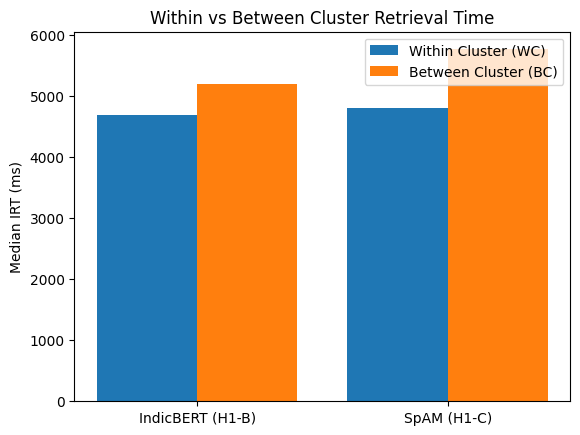

In [8]:
import matplotlib.pyplot as plt

# Combine both H1 results
labels = ["IndicBERT (H1-B)", "SpAM (H1-C)"]

wc_means = [np.median(all_wc_b), np.median(all_wc_c)]
bc_means = [np.median(all_bc_b), np.median(all_bc_c)]

x = np.arange(len(labels))

plt.figure()
plt.bar(x - 0.2, wc_means, width=0.4)
plt.bar(x + 0.2, bc_means, width=0.4)

plt.xticks(x, labels)
plt.ylabel("Median IRT (ms)")
plt.title("Within vs Between Cluster Retrieval Time")

plt.legend(["Within Cluster (WC)", "Between Cluster (BC)"])
plt.show()

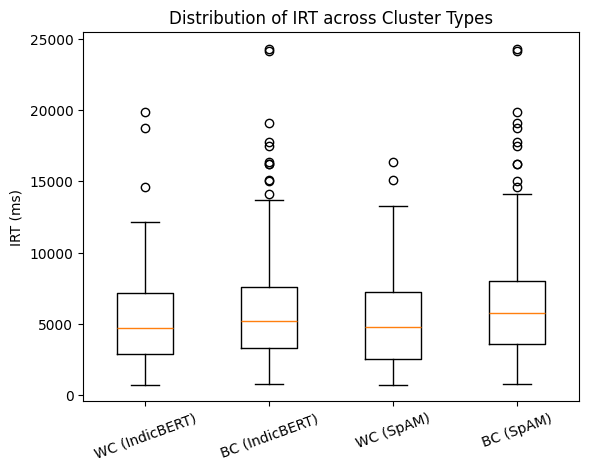

In [9]:
plt.figure()

data = [
    all_wc_b, all_bc_b,
    all_wc_c, all_bc_c
]

labels = [
    "WC (IndicBERT)", "BC (IndicBERT)",
    "WC (SpAM)", "BC (SpAM)"
]

plt.boxplot(data)
plt.xticks(range(1, 5), labels, rotation=20)

plt.ylabel("IRT (ms)")
plt.title("Distribution of IRT across Cluster Types")

plt.show()

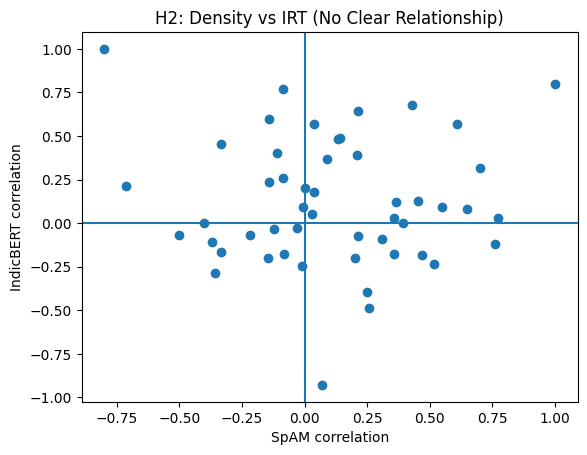

In [10]:
# Use one session example (or combine)
sample = h2c_df.iloc[:50]  # small subset

plt.figure()

plt.scatter(sample["rho_spam"], sample["rho_indic"])

plt.xlabel("SpAM correlation")
plt.ylabel("IndicBERT correlation")
plt.title("H2: Density vs IRT (No Clear Relationship)")

plt.axhline(0)
plt.axvline(0)

plt.show()

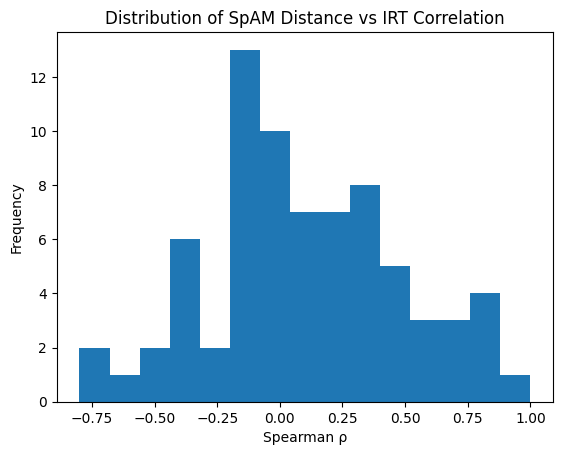

In [11]:
plt.figure()

plt.hist(h2c_df["rho_spam"], bins=15)
plt.title("Distribution of SpAM Distance vs IRT Correlation")
plt.xlabel("Spearman ρ")
plt.ylabel("Frequency")

plt.show()

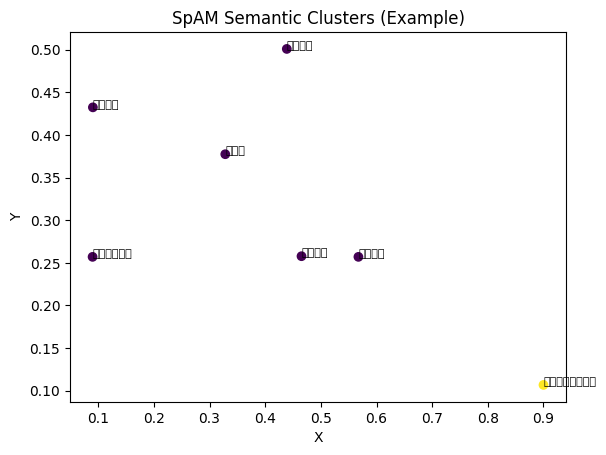

In [12]:
# pick one participant + domain
sample = spam[(spam["participant_id"] == spam["participant_id"].iloc[0]) &
              (spam["domain"] == "animals")]

coords = sample[["x_norm", "y_norm"]].values

k = max(2, int(np.sqrt(len(sample))))
labels = AgglomerativeClustering(n_clusters=k).fit_predict(coords)

plt.figure()

plt.scatter(coords[:,0], coords[:,1], c=labels)

for i, word in enumerate(sample["devnagri_word"].values):
    plt.text(coords[i,0], coords[i,1], word, fontsize=8)

plt.title("SpAM Semantic Clusters (Example)")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

# H5 “We did not find the classic serial position effect (IRT increasing over time). Instead, a mixed-effects model shows a slight decrease in IRT, suggesting participants may become faster as they continue the task.”


DATA LOADED
VFT shape: (691, 6)

H5 — SERIAL POSITION EFFECT
Sessions analysed : 80
Mean Spearman ρ   : -0.0365
Median ρ          : -0.0905
% ρ > 0           : 43.8%

Wilcoxon test (ρ > 0):
W = 1391.50, p = 0.7710 -> NOT SIGNIFICANT ✗

Domain-wise results:
Domain            Mean ρ     n
animals           -0.017    27
body-parts        -0.044    23
colours            0.327     4
foods             -0.107    26


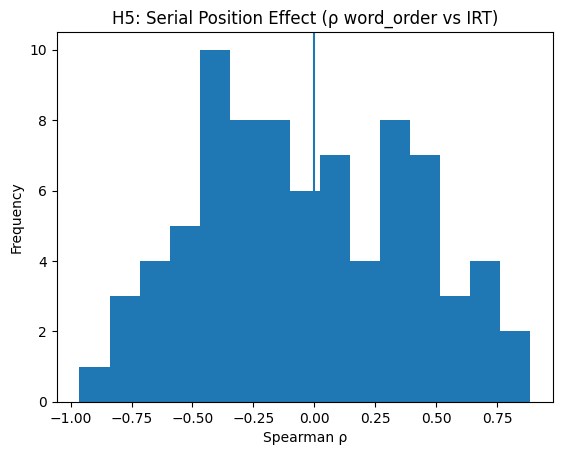

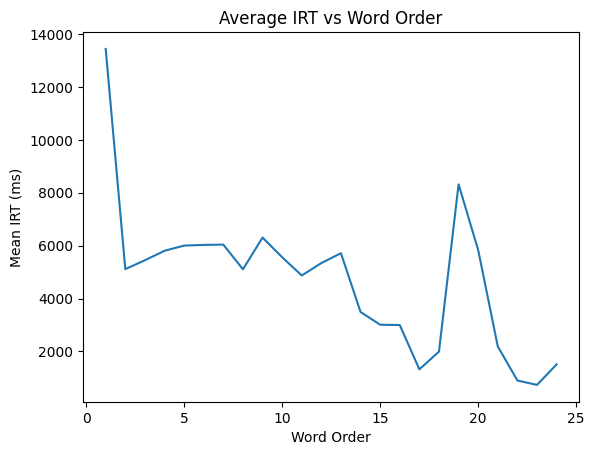


Mixed Effects Model:
              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    log_irt  
No. Observations:     691        Method:                REML     
No. Groups:           27         Scale:                 0.3362   
Min. group size:      11         Log-Likelihood:        -649.5481
Max. group size:      52         Converged:             Yes      
Mean group size:      25.6                                       
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               8.765    0.111 78.800 0.000  8.547  8.983
word_order             -0.030    0.014 -2.149 0.032 -0.058 -0.003
Group Var               0.271    0.160                           
Group x word_order Cov -0.022    0.018                           
word_order Var          0.003    0.002                           



/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [8]:
# ============================================================
# H5 — Serial Position Effect (IRT vs word_order)
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, wilcoxon
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

vft = pd.read_csv("/kaggle/input/datasets/suyashnpande/final-brsm-dataset/final_vft_data.csv")

vft["IRT"] = vft["IRT"].astype(float)
vft["word_order"] = vft["word_order"].astype(int)

print("\nDATA LOADED")
print("VFT shape:", vft.shape)

# ------------------------------------------------------------
# 2. PER SESSION CORRELATION (Spearman)
# ------------------------------------------------------------

results = []

for (pid, domain), grp in vft.groupby(["participant_id", "domain"]):

    grp = grp.sort_values("word_order")

    if len(grp) < 4:
        continue

    x = grp["word_order"].values
    y = grp["IRT"].values

    if np.std(x) < 1e-9 or np.std(y) < 1e-9:
        continue

    rho, p = spearmanr(x, y)

    results.append({
        "participant_id": pid,
        "domain": domain,
        "rho": rho,
        "p_value": p
    })

h5_df = pd.DataFrame(results)

# ------------------------------------------------------------
# 3. SUMMARY
# ------------------------------------------------------------

print("\n" + "="*60)
print("H5 — SERIAL POSITION EFFECT")
print("="*60)

print(f"Sessions analysed : {len(h5_df)}")
print(f"Mean Spearman ρ   : {h5_df['rho'].mean():.4f}")
print(f"Median ρ          : {h5_df['rho'].median():.4f}")
print(f"% ρ > 0           : {(h5_df['rho'] > 0).mean()*100:.1f}%")

# ------------------------------------------------------------
# 4. STATISTICAL TEST (Fisher-z + Wilcoxon)
# ------------------------------------------------------------

fisher_z = np.arctanh(np.clip(h5_df["rho"], -0.9999, 0.9999))

W, p = wilcoxon(fisher_z, alternative="greater")

print("\nWilcoxon test (ρ > 0):")
print(f"W = {W:.2f}, p = {p:.4f} -> "
      f"{'SIGNIFICANT ✓' if p < 0.05 else 'NOT SIGNIFICANT ✗'}")

# ------------------------------------------------------------
# 5. DOMAIN-WISE ANALYSIS
# ------------------------------------------------------------

print("\nDomain-wise results:")
print(f"{'Domain':<15} {'Mean ρ':>8} {'n':>5}")

for dom, sub in h5_df.groupby("domain"):
    print(f"{dom:<15} {sub['rho'].mean():>8.3f} {len(sub):>5}")

# ------------------------------------------------------------
# 6. VISUALIZATION — CORRELATION DISTRIBUTION
# ------------------------------------------------------------

plt.figure()

plt.hist(h5_df["rho"], bins=15)
plt.axvline(0)

plt.title("H5: Serial Position Effect (ρ word_order vs IRT)")
plt.xlabel("Spearman ρ")
plt.ylabel("Frequency")

plt.show()

# ------------------------------------------------------------
# 7. VISUALIZATION — AVERAGE CURVE
# ------------------------------------------------------------

mean_curve = vft.groupby("word_order")["IRT"].mean()

plt.figure()

plt.plot(mean_curve.index, mean_curve.values)

plt.title("Average IRT vs Word Order")
plt.xlabel("Word Order")
plt.ylabel("Mean IRT (ms)")

plt.show()

# ------------------------------------------------------------
# 8. MIXED EFFECTS MODEL
# ------------------------------------------------------------

# log transform for stability
vft["log_irt"] = np.log(vft["IRT"] + 1)

model = smf.mixedlm(
    "log_irt ~ word_order",
    data=vft,
    groups=vft["participant_id"],
    re_formula="~word_order"
)

result = model.fit()

print("\nMixed Effects Model:")
print(result.summary())

# H6

In [10]:
from scipy.stats import kruskal, mannwhitneyu
import itertools

print("\n" + "="*60)
print("H6 — DOMAIN EFFECT (CORRECTED)")
print("="*60)

# ------------------------------------------------------------
# 1. Words produced per session
# ------------------------------------------------------------

sess = (
    vft.groupby(["participant_id", "domain"], as_index=False)
    .agg(
        n_words=("word_order", "max"),
        mean_irt=("IRT", "mean")
    )
)

# ------------------------------------------------------------
# 2. KRUSKAL-WALLIS TEST
# ------------------------------------------------------------

def run_kruskal(df, column):
    groups = [group[column].values for _, group in df.groupby("domain")]
    stat, p = kruskal(*groups)

    print(f"\nKruskal-Wallis ({column}):")
    print(f"H = {stat:.3f}, p = {p:.4f} -> "
          f"{'SIGNIFICANT ✓' if p < 0.05 else 'NOT SIGNIFICANT ✗'}")

    return stat, p

run_kruskal(sess, "n_words")
run_kruskal(sess, "mean_irt")

# ------------------------------------------------------------
# 3. PAIRWISE MANN-WHITNEY (independent)
# ------------------------------------------------------------

def pairwise_mwu(df, column):
    domains = df["domain"].unique()
    pairs = list(itertools.combinations(domains, 2))

    print(f"\nPairwise Mann-Whitney ({column}):")

    for a, b in pairs:
        g1 = df[df["domain"] == a][column]
        g2 = df[df["domain"] == b][column]

        stat, p = mannwhitneyu(g1, g2, alternative="two-sided")

        print(f"{a} vs {b}: U={stat:.1f}, p={p:.4f}")

pairwise_mwu(sess, "n_words")
pairwise_mwu(sess, "mean_irt")

# ------------------------------------------------------------
# 4. SIMPLE SUMMARY
# ------------------------------------------------------------

summary = sess.groupby("domain").agg({
    "n_words": "mean",
    "mean_irt": "mean"
}).reset_index()

print("\nSummary:")
print(summary)


H6 — DOMAIN EFFECT (CORRECTED)

Kruskal-Wallis (n_words):
H = 2.684, p = 0.4430 -> NOT SIGNIFICANT ✗

Kruskal-Wallis (mean_irt):
H = 3.124, p = 0.3728 -> NOT SIGNIFICANT ✗

Pairwise Mann-Whitney (n_words):
animals vs body-parts: U=337.0, p=0.6100
animals vs foods: U=430.0, p=0.2527
animals vs colours: U=40.5, p=0.4376
body-parts vs foods: U=334.5, p=0.6430
body-parts vs colours: U=30.0, p=0.2866
foods vs colours: U=29.5, p=0.1436

Pairwise Mann-Whitney (mean_irt):
animals vs body-parts: U=303.0, p=0.8916
animals vs foods: U=316.0, p=0.4063
animals vs colours: U=79.0, p=0.1541
body-parts vs foods: U=277.0, p=0.5206
body-parts vs colours: U=66.0, p=0.1910
foods vs colours: U=80.0, p=0.1370

Summary:
       domain    n_words     mean_irt
0     animals   8.629630  7207.220992
1  body-parts   8.347826  7371.599564
2     colours  10.250000  5392.524444
3       foods   8.333333  7686.505132
